In [1]:
import numpy as np
from training_data import Nopealizer, load_training_data
import matplotlib.pyplot as plt

In [2]:
save_path = "models/test_pytorch_output"
training_data_path = "training_data"

In [3]:
onehot_size = 500
# norm = OneHotNormalizer(range=[[-100, 0, 0], [100, 500, 500]], size=onehot_size)
# norm = Nopealizer()
all_training_data = load_training_data(training_data_path)#, norm=norm)
levels = list(all_training_data.levels.keys())


In [4]:
# The training data loaded above is a MultiLevelTrainingData instance.
# Choose a single level to train on:
training_level = 'd0.00'
training_data = all_training_data.get_level(training_level)

# disable normalization; we'll do that later
training_data.input_norm = None
training_data.output_norm = None

In [10]:
# training_data.generator(batch_size) returns a generator that yields batches of training data.
# each example is a tuple (input, output) where input is a 3D numpy array of shape (batch_size, height, width)
# and output is a 2D numpy array of shape (batch_size, 3*onehot_vector_size). Each output contains 3 one-hot vectors
# representing the x, y, and z coordinates of the target. For now, we will ignore the z axis.

# Build a pytorch model consisting of:
# - a resnet101v2 pretrained on imagenet, excluding its final classification layer
#    (the final layer has output shape (batch_size, M, N, channels)
# - a max pooling layer that takes the maximum only over channels (output shape (batch_size, M, N))
# - a dense layer with 3 one-hot outputs (output shape (batch_size, 3, onehot_size))

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

print("CUDA:", torch.cuda.is_available())

class PipetteDetector(nn.Module):
    def __init__(self, onehot_size=500):
        super(PipetteDetector, self).__init__()
        resnet101 = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2)
        self.resnet = torch.nn.Sequential(*(list(resnet101.children())[:-2]))

        # freeze parameters for all but last block (10 layers) of the resnet
        for param in self.resnet.parameters():
            param.requires_grad = False
        # for param in self.resnet[-1][-1].parameters():
        #     param.requires_grad = True
            
        # global average pooling 2d
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))

        # max pooling 2d
        # self.pooling = nn.MaxPool2d(kernel_size=2, stride=2)

        # self.layers = torch.nn.Sequential(
        #     nn.LazyConv2d(4, kernel_size=3, stride=1, padding=1),
        #     nn.ReLU(),
        #     nn.LazyConv2d(8, kernel_size=7, stride=1, padding=3),
        #     nn.ReLU(),
        #     nn.LazyConv2d(16, kernel_size=15, stride=1, padding=7),
        #     nn.ReLU(),
        #     nn.LazyConv2d(16, kernel_size=15, stride=1, padding=7),
        #     nn.ReLU(),
        #     nn.LazyConv2d(16, kernel_size=15, stride=1, padding=7),
        #     nn.ReLU(),
        # )

        # If output size is currently (channels, height, width), add a convolutional layer with kernel size (height, 1) and output size (1, onehot_size)
        # output_shape = (13, 13)
        # self.x_conv = nn.LazyConv2d((onehot_size // output_shape[1]) + 1, kernel_size=(output_shape[0], 1))
        # self.y_conv = nn.LazyConv2d((onehot_size // output_shape[0]) + 1, kernel_size=(1, output_shape[1]))
        # self.z_conv = nn.LazyConv2d((onehot_size // output_shape[0]) + 1, kernel_size=(1, output_shape[1]))

        self.xyz_out = nn.LazyLinear(3)

    def forward(self, input):
        resnet_output = self.resnet(input)

        # x = self.x_conv(resnet_output)
        # y = self.y_conv(resnet_output)
        # # flatten x and y
        # x = x.reshape(x.size(0), -1)
        # y = y.reshape(y.size(0), -1)
        # # crop to onehot_size
        # x = x[:, :onehot_size]
        # y = y[:, :onehot_size]

        pooled = self.pooling(resnet_output)

        flat = pooled.reshape(pooled.size(0), -1)
        # flat = input.reshape(input.size(0), -1)
        # flat = resnet_output.reshape(resnet_output.size(0), -1)

        # output = self.layers(input)
        # flat = output.reshape(output.size(0), -1)
        xyz = self.xyz_out(flat)
        return xyz
    
# initialize a model just to see its structure
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_model = PipetteDetector()
test_model.to(device);
# print(model)


CUDA: True


In [11]:
test_model.resnet[-1][-1]   # the frozen block

Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)

In [12]:
from torchsummary import summary

summary(test_model, input_size=(3, 400, 400))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 200, 200]           9,408
       BatchNorm2d-2         [-1, 64, 200, 200]             128
              ReLU-3         [-1, 64, 200, 200]               0
         MaxPool2d-4         [-1, 64, 100, 100]               0
            Conv2d-5         [-1, 64, 100, 100]           4,096
       BatchNorm2d-6         [-1, 64, 100, 100]             128
              ReLU-7         [-1, 64, 100, 100]               0
            Conv2d-8         [-1, 64, 100, 100]          36,864
       BatchNorm2d-9         [-1, 64, 100, 100]             128
             ReLU-10         [-1, 64, 100, 100]               0
           Conv2d-11        [-1, 256, 100, 100]          16,384
      BatchNorm2d-12        [-1, 256, 100, 100]             512
           Conv2d-13        [-1, 256, 100, 100]          16,384
      BatchNorm2d-14        [-1, 256, 1

In [14]:
from training_data import Normalizer

# decide how to transform data
img_normalizer = lambda x: x / 255
pos_normalizer = Normalizer(range=[[-100, 0, 0], [100, 500, 500]])

# initialize the model
model = PipetteDetector()
model.to(device)

# Define a loss function and optimizer
# criterion = nn.CrossEntropyLoss() # expects labels to be class index (not one-hot)
# criterion = nn.BCEWithLogitsLoss()  # expects labels to be one-hot (or multi-hot)
criterion = nn.MSELoss()  # for regression
optimizer = optim.Adam(model.parameters(), lr=0.00001)
# scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)

# Train the model
batch_size = 128
losses = []
try:
    for i, data in enumerate(training_data.generator(batch_size)):
        # inputs is a 4D numpy array of shape (batch_size, height, width, channels), normalized to [0, 1]
        # labels is a 2D numpy array of shape (batch_size, 3), normalized using training_data.output_norm
        inputs, labels = data

        inputs = img_normalizer(inputs).transpose((0, 3, 1, 2))
        inputs_t = torch.tensor(inputs, dtype=torch.float32).to(device)
        
        normed_labels = pos_normalizer.normalize(labels)
        labels_t = torch.tensor(normed_labels, dtype=torch.float32).to(device)

        # zero the parameter gradients (otherwise they accumulate)
        optimizer.zero_grad()

        # run model, calculate loss, and backpropagate
        out = model(inputs_t)
        loss = criterion(out, labels_t)
        loss.backward()
        optimizer.step()
        # scheduler.step()

        # track loss over time
        losses.append(loss.item())
        if i % 10 == 9:
            # for name, param in model.named_parameters():
            #     if param.requires_grad:
            #         print(name, param.grad)
            recent = np.array(losses[-100:])
            print(f'[step {i:06d}] recent average loss: {(recent**0.5).mean():0.6f}  final loss: {recent[-1]**0.5:0.6f}')
            # print(f'      learning rate: {scheduler.get_last_lr()[0]}  ')
            # calculate fraction of predictions that are within 5 pixels of the target
            correct = (((out - labels_t)[:, 1:3]**2).sum(dim=1).sqrt() < 0.01).sum()
            print(f'              correct: {100 * correct / batch_size}%  ({correct}/{batch_size})')
            
        if i % 100 == 99:
            torch.save(model.state_dict(), save_path)

        # del inputs_t, labels_t
        torch.cuda.empty_cache()
except KeyboardInterrupt:
    print('Interrupted, saving..')
    torch.save(model.state_dict(), save_path)

print('Finished Training')


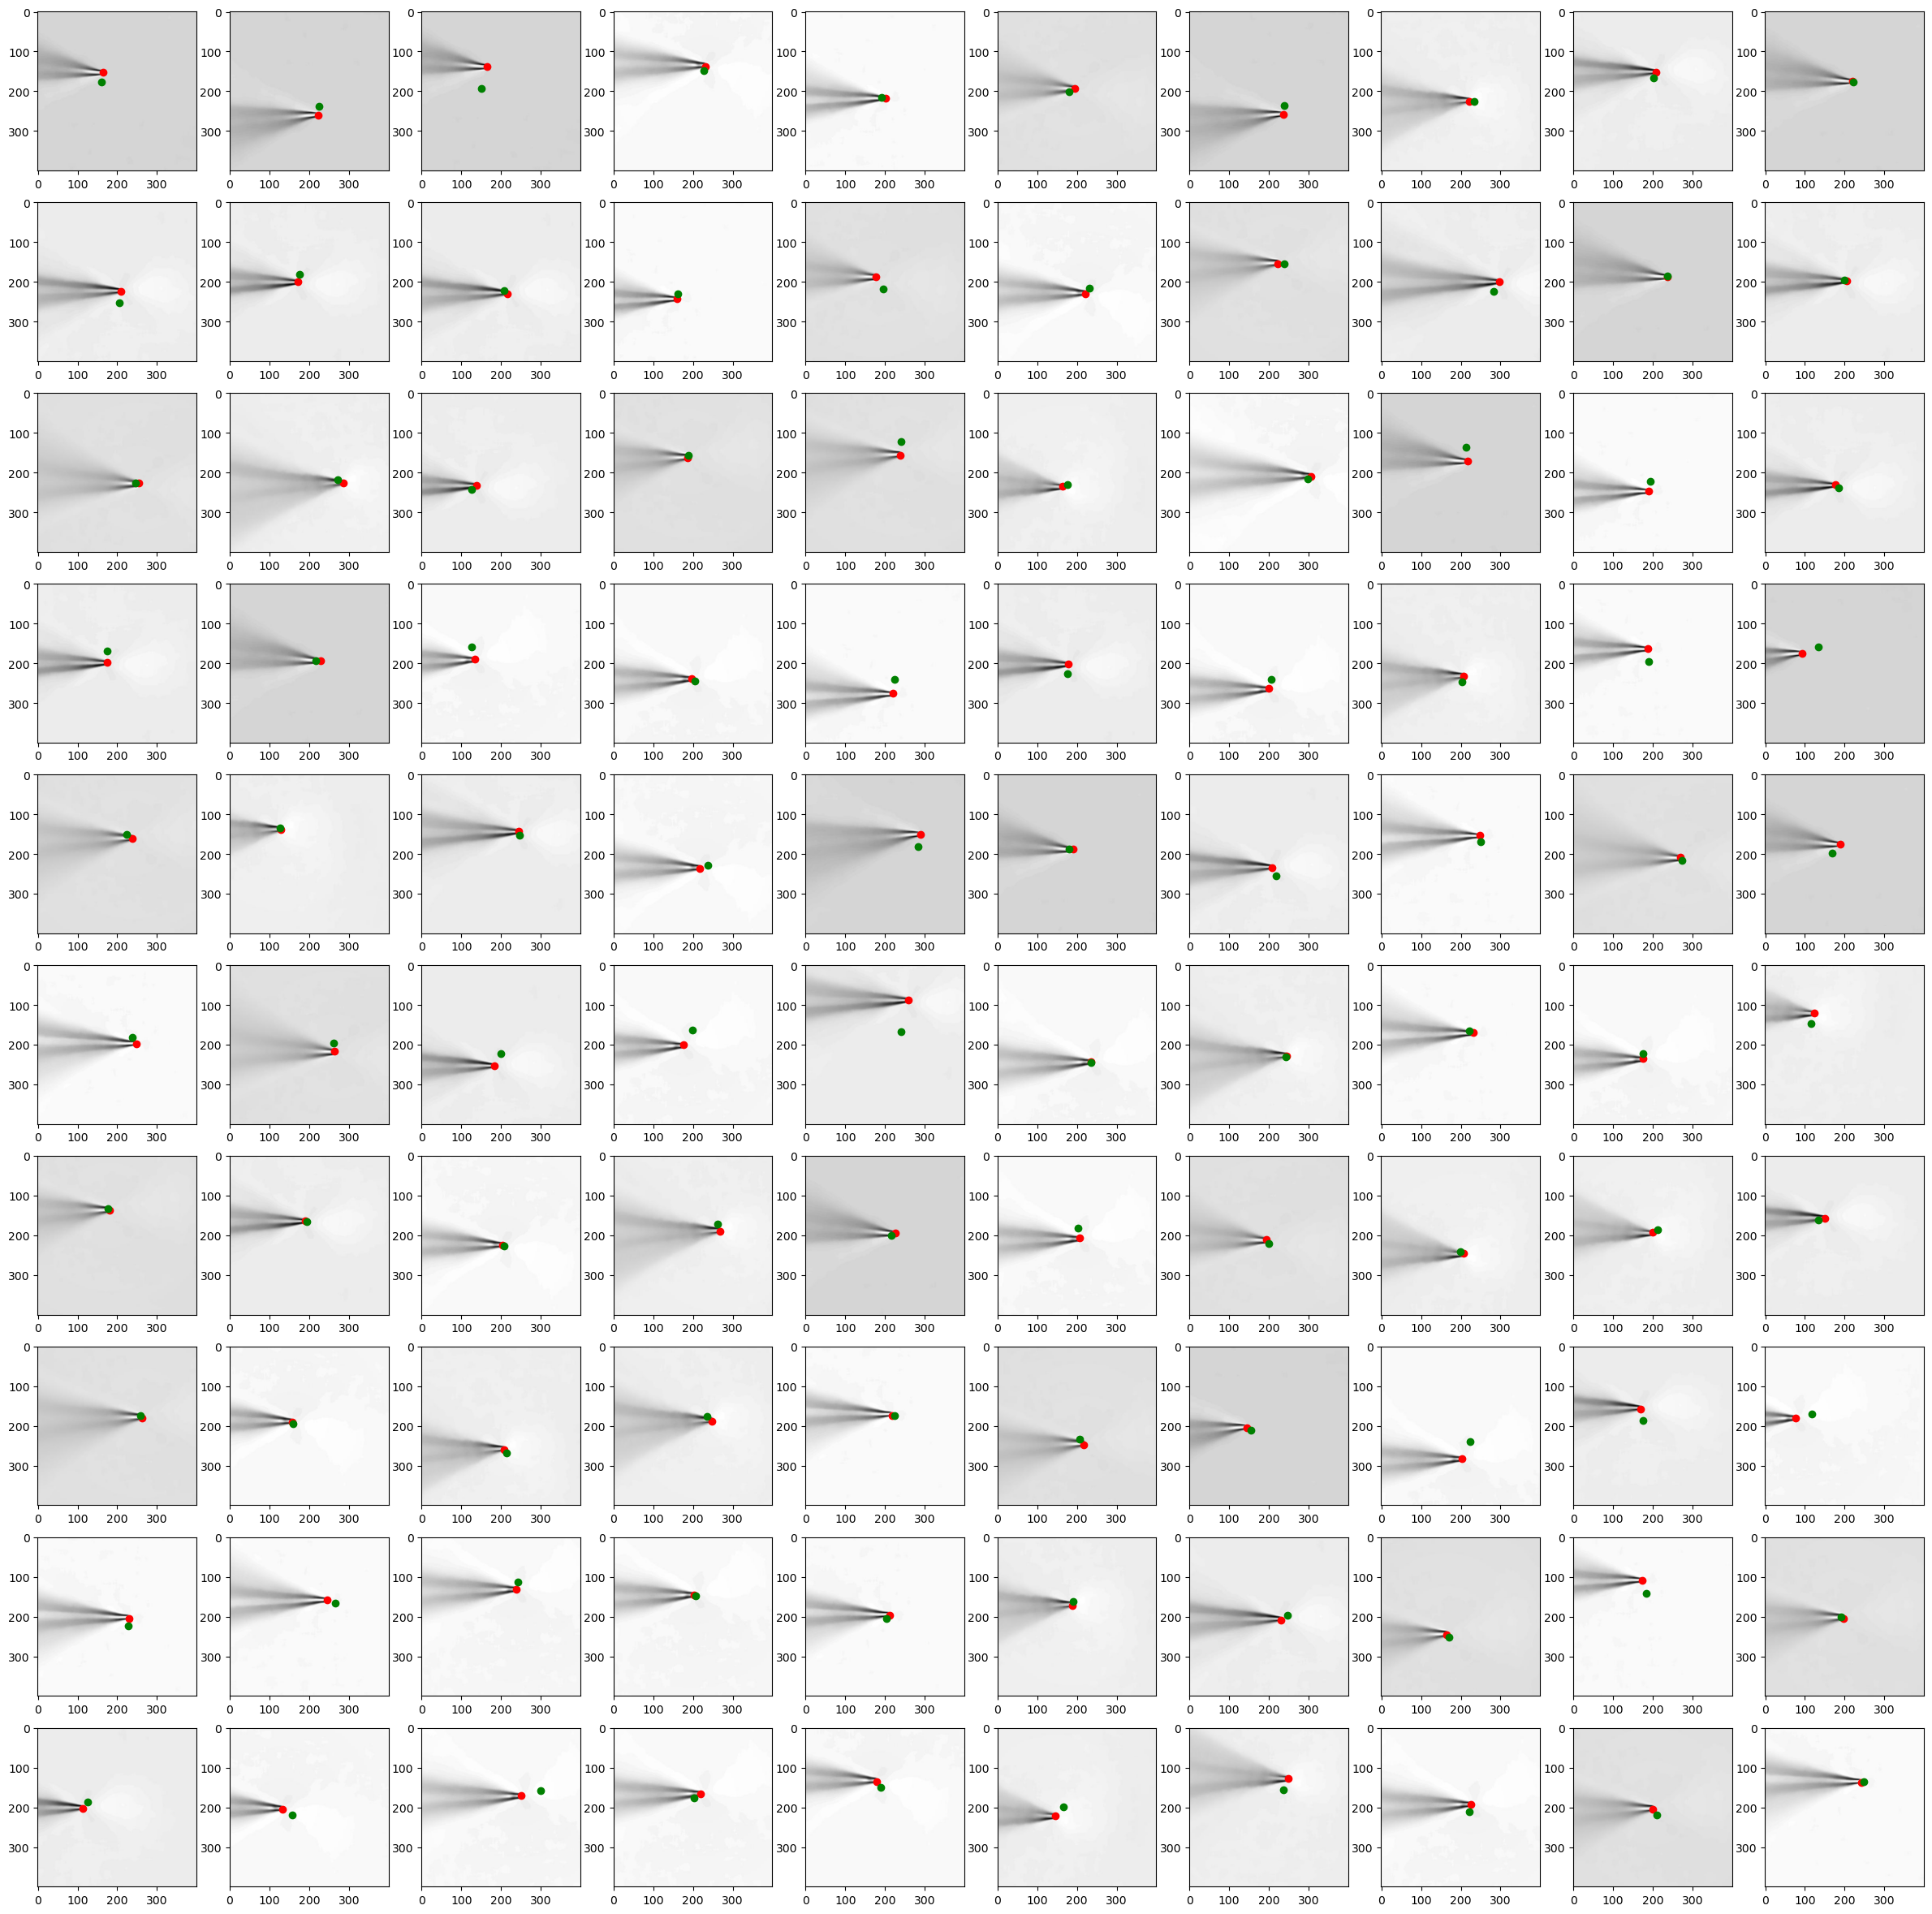

In [ ]:
shape = (10, 10)
fig, ax = plt.subplots(shape[0], shape[1], figsize=(shape[1]*3, shape[0]*3))

image, pip_pos = training_data[:shape[0]*shape[1]].get_arrays()
# pip_pos = training_data.output_norm.denormalize(pip_pos)
# use model in inference mode to make prediction from image
model.eval()
with torch.no_grad():
    image_normed = img_normalizer(image).transpose((0, 3, 1, 2))
    image_tensor = torch.tensor(image_normed, dtype=torch.float32).to(device)

    pred = model(image_tensor).cpu().numpy()
    pred = pos_normalizer.denormalize(pred)


for i, axi in enumerate(ax.flatten()):
    # pred = training_data.output_norm.denormalize(model.model.predict(image))
    axi.imshow(image[i], cmap='gray')
    axi.scatter(pip_pos[i, 2], pip_pos[i, 1], color='red')
    axi.scatter(pred[i, 2], pred[i, 1], color='green')

